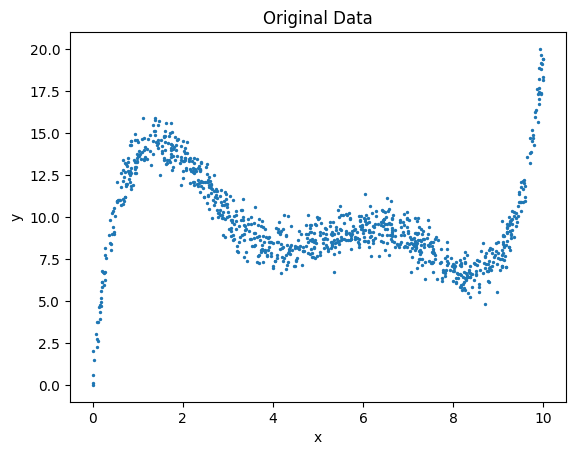

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

df = pd.read_csv('mlp_regression_data.csv')
X = df['x'].values.astype('float32')
y = df['y'].values.astype('float32')

plt.scatter(X, y, s=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Original Data')
plt.show()

In [2]:
x_mean, x_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - x_mean) / x_std
y_norm = (y - y_mean) / y_std

# Convert to tensors here
X_tensor = torch.tensor(X_norm).view(-1, 1)
y_tensor = torch.tensor(y_norm).view(-1, 1)

In [3]:
print(f"x_mean: {x_mean:.4f}")
print(f"x_std: {x_std:.4f}")
print(f"y_mean: {y_mean:.4f}")
print(f"y_std: {y_std:.4f}")

x_mean: 5.0647
x_std: 2.8683
y_mean: 9.7616
y_std: 2.7745


In [4]:
from torch.utils.data import TensorDataset

dataset = TensorDataset(X_tensor, y_tensor)
batch_size = 32
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [5]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim=1, hidden1=50, hidden2=25, output_dim=1, activation=nn.ReLU()):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, output_dim)
        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)   # No activation
        return x

In [6]:
# Define general purpose training function
def train_model(model, optimizer, criterion, train_loader, dataset, num_epochs=200):
    train_losses = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * X_batch.size(0)
        avg_loss = epoch_loss / len(dataset)
        train_losses.append(avg_loss)
        if (epoch + 1) % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')
    return train_losses

In [7]:
# Establish combo 1 —> ReLU, Adam, lr=0.01, batch_size=32
model1 = MLPRegressor(activation=nn.ReLU())
criterion = nn.MSELoss()
optimizer1 = optim.Adam(model1.parameters(), lr=0.01)
print("Combo 1: ReLU, Adam, lr=0.01, batch_size=32")
losses1 = train_model(model1, optimizer1, criterion, train_loader, dataset)

Combo 1: ReLU, Adam, lr=0.01, batch_size=32
Epoch [50/200], Loss: 0.103171
Epoch [100/200], Loss: 0.101198
Epoch [150/200], Loss: 0.078416
Epoch [200/200], Loss: 0.079700


In [8]:
# Establish combo 2 —> Tanh, Adam, lr=0.01, batch_size=32
model2 = MLPRegressor(activation=nn.Tanh())
optimizer2 = optim.Adam(model2.parameters(), lr=0.01)
print("Combo 2: Tanh, Adam, lr=0.01, batch_size=32")
losses2 = train_model(model2, optimizer2, criterion, train_loader, dataset)

Combo 2: Tanh, Adam, lr=0.01, batch_size=32
Epoch [50/200], Loss: 0.084520
Epoch [100/200], Loss: 0.092326
Epoch [150/200], Loss: 0.103904
Epoch [200/200], Loss: 0.092916


In [9]:
# Establish combo 3 —> Tanh, Adam, lr=0.001, batch_size=64
dataset3 = TensorDataset(X_tensor, y_tensor)
train_loader3 = DataLoader(dataset3, batch_size=64, shuffle=True)
model3 = MLPRegressor(activation=nn.Tanh())
optimizer3 = optim.Adam(model3.parameters(), lr=0.001)
print("Combo 3: Tanh, Adam, lr=0.001, batch_size=64")
losses3 = train_model(model3, optimizer3, criterion, train_loader3, dataset3)

Combo 3: Tanh, Adam, lr=0.001, batch_size=64
Epoch [50/200], Loss: 0.398759
Epoch [100/200], Loss: 0.120925
Epoch [150/200], Loss: 0.074076
Epoch [200/200], Loss: 0.072171


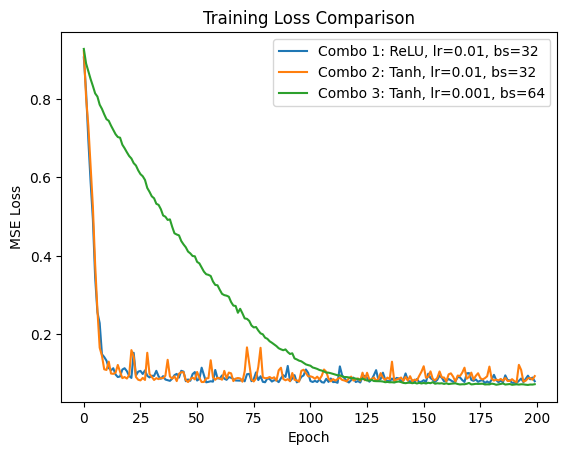

In [10]:
# Plot all training losses together
plt.figure()
plt.plot(losses1, label='Combo 1: ReLU, lr=0.01, bs=32')
plt.plot(losses2, label='Combo 2: Tanh, lr=0.01, bs=32')
plt.plot(losses3, label='Combo 3: Tanh, lr=0.001, bs=64')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.show()

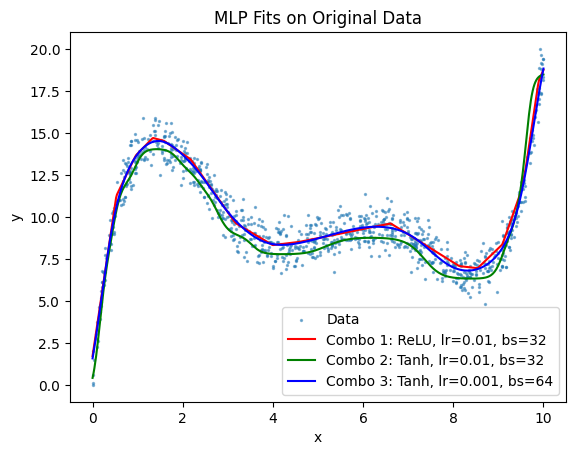

In [11]:
# Overlay fitted curves on original data
import numpy as np

model1.eval()
model2.eval()
model3.eval()

x_range = np.linspace(X.min(), X.max(), 500).astype('float32')
x_range_norm = (x_range - x_mean) / x_std
x_range_tensor = torch.tensor(x_range_norm).view(-1, 1)

with torch.no_grad():
    y_pred1 = model1(x_range_tensor).numpy().flatten() * y_std + y_mean
    y_pred2 = model2(x_range_tensor).numpy().flatten() * y_std + y_mean
    y_pred3 = model3(x_range_tensor).numpy().flatten() * y_std + y_mean

plt.figure()
plt.scatter(X, y, s=2, label='Data', alpha=0.5)
plt.plot(x_range, y_pred1, label='Combo 1: ReLU, lr=0.01, bs=32', color='red')
plt.plot(x_range, y_pred2, label='Combo 2: Tanh, lr=0.01, bs=32', color='green')
plt.plot(x_range, y_pred3, label='Combo 3: Tanh, lr=0.001, bs=64', color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.title('MLP Fits on Original Data')
plt.legend()
plt.show()

In [12]:
print(f"Combo 1 final loss: {losses1[-1]:.6f}")
print(f"Combo 2 final loss: {losses2[-1]:.6f}")
print(f"Combo 3 final loss: {losses3[-1]:.6f}")

Combo 1 final loss: 0.079700
Combo 2 final loss: 0.092916
Combo 3 final loss: 0.072171
